## Biweekly 20.01

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats
from scipy.stats import chi2_contingency
from typing import Callable

def _resolve_project_root() -> Path:
    """locate project root containing config.py."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            print(candidate)
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')


PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import GENE_PATHS, SOURCE_PALETTE, VARIANT_PATHS

/Users/markus/in-silico-vg-analysis


In [2]:
def _dedup_scores_by_variant(
    path: str | Path,
    label: str,
    columns: list[str] | None = None
) -> pl.DataFrame:
    """deduplicate scores by variant, keeping max absolute score.
    
    args:
        path (str | Path): parquet file path.
        label (str): dataset label for logging.
        columns (list[str] | None): additional columns to keep (e.g. ['AF'], ['perm_AF']).
    
    returns:
        pl.DataFrame: deduplicated variant table with gene_id, variant_id, raw_score, and requested columns.
    """
    df = pl.read_parquet(path)
    print(f"  loaded {label}: {df.shape}")
    
    # required columns
    required = ['variant_id', 'gene_id', 'raw_score']
    if columns:
        required.extend(columns)
    
    # select needed columns
    df = df.select(required)
    
    # deduplicate by keeping variant with max absolute score
    dedup = (
        df
        .with_columns(pl.col('raw_score').abs().alias('_abs_score'))
        .sort('_abs_score', descending=True)
        .unique(subset=['variant_id'], keep='first')
        .drop('_abs_score')
    )
    
    print(f"  after dedup: {dedup.shape}")
    return dedup

In [3]:
# DEBUG CELL: deduplicate and downsample variants for both datasets
from pathlib import Path
import polars as pl
import pandas as pd
import numpy as np

print("=== DEDUPLICATION AND DOWNSAMPLING ===")
print("PROJECT ROOT:", Path.cwd())

# configuration for both datasets
datasets_config = {
    'clingen': {
        'real_var': VARIANT_PATHS['clingen'],
        'null_var': VARIANT_PATHS['clingen_null'],
        'real_gene': GENE_PATHS['clingen'],
    },
    'background': {
        'real_var': VARIANT_PATHS['background'],
        'null_var': VARIANT_PATHS['background_null'],
        'real_gene': GENE_PATHS['background'],
    },
}

print("\n=== INPUT FILES ===")
for dataset_name, config in datasets_config.items():
    print(f"\n{dataset_name.upper()}:")
    print(f"  real_var:  {config['real_var']}")
    print(f"  null_var:  {config['null_var']}")
    print(f"  real_gene: {config['real_gene']}")

# storage for final dataframes
final_dataframes = {}

# helper function for downsampling
def downsample_null_to_real(null_df: pl.DataFrame, real_counts_df: pl.DataFrame, seed: int = 42) -> pl.DataFrame:
    """downsample null variants to match real variant counts per gene."""
    n_map = real_counts_df.select(["gene_id", "n_variants"]).to_pandas().set_index("gene_id")["n_variants"].to_dict()
    pdf = null_df.to_pandas()
    sampled_parts = []
    
    for gene, group in pdf.groupby("gene_id"):
        n_req = int(n_map.get(gene, 0))
        if n_req <= 0:
            continue
        avail = len(group)
        if avail == 0:
            continue
        if avail <= n_req:
            sampled_parts.append(group)
        else:
            taken = group.sample(n=n_req, random_state=seed)
            sampled_parts.append(taken)
    
    if sampled_parts:
        sampled_pdf = pd.concat(sampled_parts, axis=0)
        return pl.from_pandas(sampled_pdf)
    else:
        return pl.DataFrame(schema=null_df.schema)

# process both datasets
for dataset_name, config in datasets_config.items():
    print(f"\n{'='*60}")
    print(f"PROCESSING: {dataset_name.upper()}")
    print(f"{'='*60}")
    
    # load gene table
    real_gene = pl.read_parquet(config['real_gene'])
    print(f"\nreal genes: {real_gene.shape[0]} genes, {real_gene['n_variants'].sum()} total variants")
    print(f"mean: {real_gene['n_variants'].mean():.1f}, median: {real_gene['n_variants'].median():.0f}")
    
    # deduplicate real variants (keep AF column)
    print(f"deduplicating real variants...")
    real_dedup = _dedup_scores_by_variant(config['real_var'], label=f"{dataset_name}_real", columns=['AF'])
    print(f"real dedup: {real_dedup.shape}")
    
    # deduplicate null variants (keep perm_AF column)
    print(f"deduplicating null variants...")
    null_dedup = _dedup_scores_by_variant(config['null_var'], label=f"{dataset_name}_null", columns=['perm_AF'])
    print(f"null dedup: {null_dedup.shape}")
    
    # variant availability check
    null_counts = null_dedup.group_by("gene_id").agg(pl.len().alias("n_null_available"))
    cmp = (
        real_gene.select(["gene_id", "n_variants"])
        .join(null_counts, on="gene_id", how="left")
        .with_columns(pl.col("n_null_available").fill_null(0).cast(pl.Int64))
    )
    
    capped = cmp.filter(pl.col("n_null_available") < pl.col("n_variants"))
    if capped.height > 0:
        deficit = (capped['n_variants'] - capped['n_null_available']).sum()
        print(f"⚠️  {capped.height} genes capped (total deficit: {deficit} variants)")
    else:
        print(f"✓ all genes have sufficient null variants")
    
    # downsample null to match real counts
    print(f"downsampling null variants to match real counts...")
    null_sampled = downsample_null_to_real(null_dedup, real_gene, seed=42)
    print(f"null sampled: {null_sampled.shape}")
    
    # store final dataframes
    final_dataframes[f'{dataset_name}_real_dedup'] = real_dedup
    final_dataframes[f'{dataset_name}_null_sampled'] = null_sampled

# extract final dataframes as variables
print(f"\n{'='*60}")
print("FINAL DATAFRAMES")
print(f"{'='*60}")

clingen_real_dedup = final_dataframes['clingen_real_dedup']
clingen_null_sampled = final_dataframes['clingen_null_sampled']
background_real_dedup = final_dataframes['background_real_dedup']
background_null_sampled = final_dataframes['background_null_sampled']

print(f"\nclingen_real_dedup: {clingen_real_dedup.shape}")
print(f"clingen_null_sampled: {clingen_null_sampled.shape}")
print(f"background_real_dedup: {background_real_dedup.shape}")
print(f"background_null_sampled: {background_null_sampled.shape}")

print("\n✓ all dataframes ready for analysis")
print("\n=== Gene Overlap ===")
real_genes = real_gene.select(pl.col("gene_id").unique())
null_genes = null_dedup.select(pl.col("gene_id").unique())
overlap = real_genes.join(null_genes, on="gene_id", how="inner").height
print(f"unique real genes: {real_genes.height}")
print(f"unique null genes: {null_genes.height}")
print(f"gene overlap: {overlap}")

# 4) Variant availability per gene
print("\n=== Variant Availability ===")
null_counts = null_dedup.group_by("gene_id").agg(pl.len().alias("n_null_available"))
print(f"null variants per gene stats:")
print(null_counts.select('n_null_available').describe())

cmp = (
    real_gene.select(["gene_id", "n_variants"])
    .join(null_counts, on="gene_id", how="left")
    .with_columns(pl.col("n_null_available").fill_null(0).cast(pl.Int64))
)

missing = cmp.filter(pl.col("n_null_available") == 0)
print(f"\nreal genes missing from null: {missing.height}")
if missing.height > 0:
    print(missing.select(["gene_id", "n_variants"]).head(10))

# 5) Genes capped (insufficient null variants)
print("\n=== Capped Genes (null < requested) ===")
capped = cmp.filter(pl.col("n_null_available") < pl.col("n_variants"))
print(f"genes capped: {capped.height}")
if capped.height > 0:
    capped_detail = (
        capped.with_columns((pl.col("n_variants") - pl.col("n_null_available")).alias("deficit"))
        .sort("deficit", descending=True)
        .select(["gene_id", "n_variants", "n_null_available", "deficit"])
    )
    print(f"total deficit (missing variants): {capped_detail['deficit'].sum()}")
    print(capped_detail.head(10))

# 6) Genes with surplus null variants
print("\n=== Surplus Genes (null > requested) ===")
surplus = cmp.filter(pl.col("n_null_available") > pl.col("n_variants"))
print(f"genes with surplus: {surplus.height}")
if surplus.height > 0:
    surplus_detail = (
        surplus.with_columns((pl.col("n_null_available") - pl.col("n_variants")).alias("surplus"))
        .sort("surplus", descending=True)
        .select(["gene_id", "n_variants", "n_null_available", "surplus"])
    )
    print(f"total surplus (extra variants available): {surplus_detail['surplus'].sum()}")
    print("top 10 largest surpluses:")
    print(surplus_detail.head(10).to_pandas())

# 7) Sample variants from problematic genes
print("\n=== Sample Variants from Top Capped Genes ===")
def sample_rows_for_gene(gene_id, n=5):
    print(f"\nsample rows for gene {gene_id}:")
    print(null_dedup.filter(pl.col("gene_id") == gene_id).head(n).to_pandas())

example_genes = []
if capped.height > 0:
    example_genes = capped.sort((pl.col("n_variants") - pl.col("n_null_available")), descending=True).select("gene_id").head(3).to_pandas()["gene_id"].tolist()
elif missing.height > 0:
    example_genes = missing.select("gene_id").head(3).to_pandas()["gene_id"].tolist()
else:
    example_genes = surplus.sort("n_null_available", descending=True).select("gene_id").head(3).to_pandas()["gene_id"].tolist()

for g in example_genes:
    sample_rows_for_gene(g)

# 8) Downsampling with verbose tracking
print("\n=== Downsampling Null Variants ===")
def downsample_verbose(null_df: pl.DataFrame, real_counts_df: pl.DataFrame, seed=42):
    """Return (sampled_pl_df, report_df) where report_df lists per-gene requested, available, taken."""
    # pandas approach for sampling like previous implementation, but produce report
    n_map = real_counts_df.select(["gene_id", "n_variants"]).to_pandas().set_index("gene_id")["n_variants"].to_dict()
    pdf = null_df.to_pandas()
    reports = []
    sampled_parts = []

    rng = np.random.RandomState(seed)

    # groupby gene in pandas for deterministic sampling
    for gene, group in pdf.groupby("gene_id"):
        n_req = int(n_map.get(gene, 0))
        avail = len(group)
        if n_req <= 0:
            # skip entirely
            reports.append({"gene_id": gene, "n_req": n_req, "n_avail": avail, "n_taken": 0, "capped": True})
            continue
        if avail == 0:
            reports.append({"gene_id": gene, "n_req": n_req, "n_avail": 0, "n_taken": 0, "capped": True})
            continue
        if avail <= n_req:
            # take all
            sampled_parts.append(group)
            reports.append({"gene_id": gene, "n_req": n_req, "n_avail": avail, "n_taken": avail, "capped": avail < n_req})
            continue
        # avail > n_req: sample without replacement deterministically
        taken = group.sample(n=n_req, random_state=seed)  # seed provides deterministic
        sampled_parts.append(taken)
        reports.append({"gene_id": gene, "n_req": n_req, "n_avail": avail, "n_taken": n_req, "capped": False})

    if sampled_parts:
        sampled_pdf = pd.concat(sampled_parts, axis=0)
    else:
        sampled_pdf = pd.DataFrame(columns=pdf.columns)

    report_df = pd.DataFrame(reports)
    return pl.from_pandas(sampled_pdf), pl.from_pandas(report_df)

sampled_ds, report = downsample_verbose(null_dedup, real_gene, seed=42)
print("downsampling complete")
print(f"sampled dataset shape: {sampled_ds.shape}")
print(f"genes capped during sampling: {report.filter(pl.col('n_taken') < pl.col('n_req')).height}")

# 9) Downsampling report details
print("\n=== Downsampling Report ===")
print(report.describe())

capped_report = report.filter(pl.col('n_taken') < pl.col('n_req')).sort(['n_req', 'n_avail'], descending=[True, False])
if capped_report.height > 0:
    print(f"\ntop {min(10, capped_report.height)} capped genes (largest requested):")
    print(capped_report.head(10))

# 10) Save debug artifacts
report_path = Path.cwd() / "downsample_debug_report.parquet"
print(f"\nsaving report to {report_path}")
report.write_parquet(report_path, statistics=True)

# 11) Final sanity check: compare requested vs sampled
print("\n=== Final Sanity Check ===")
sampled_counts = sampled_ds.group_by("gene_id").agg(pl.count().alias("n_sampled"))
cmp2 = real_gene.select(["gene_id", "n_variants"]).join(sampled_counts, on="gene_id", how="left").with_columns(pl.col("n_sampled").fill_null(0).cast(pl.Int64))
diffs = cmp2.with_columns((pl.col("n_variants") - pl.col("n_sampled")).alias("diff"))
print("diffs (requested - sampled):")
print(diffs.select(pl.col("diff")).describe())

diff_examples = diffs.filter(pl.col("diff") > 0).sort("diff", descending=True)
if diff_examples.height > 0:
    print(f"\n{diff_examples.height} genes with diff > 0 (top 10):")
    print(diff_examples.head(10).to_pandas())
else:
    print("\nno genes with deficit (all matched perfectly)")

print("\n=== Diagnostics Complete ===")

=== DEDUPLICATION AND DOWNSAMPLING ===
PROJECT ROOT: /Users/markus/in-silico-vg-analysis/02_vg_perm

=== INPUT FILES ===

CLINGEN:
  real_var:  /Users/markus/in-silico-vg-analysis/experiments_data/dataset3_ClinGen/dataset3_clingen_variant_level_summary.parquet
  null_var:  /Users/markus/in-silico-vg-analysis/experiments_data/dataset5_NULL/dataset5_ClinGen_NULL_variant_level_summary_1901.parquet
  real_gene: /Users/markus/in-silico-vg-analysis/experiments_data/dataset3_ClinGen/clingen_genes_20260102.parquet

BACKGROUND:
  real_var:  /Users/markus/in-silico-vg-analysis/experiments_data/dataset4_background/background_variants_20251230.parquet
  null_var:  /Users/markus/in-silico-vg-analysis/experiments_data/dataset5_NULL/dataset5_Background_NULL_variant_level_summary_1901.parquet
  real_gene: /Users/markus/in-silico-vg-analysis/experiments_data/dataset4_background/background_genes_20260102.parquet

PROCESSING: CLINGEN

real genes: 316 genes, 1446682 total variants
mean: 4578.1, median: 44

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_64633/4005537317.py:252: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  sampled_counts = sampled_ds.group_by("gene_id").agg(pl.count().alias("n_sampled"))


ClinGen_HI real dedup shape: (1446682, 4)
ClinGen_HI null sampled shape: (1285499, 4)

ClinGen_HI SUMMARY STATISTICS

variant counts:
  real: 1446682 variants, 287 genes
  null: 1285499 variants, 287 genes

global AF statistics:
  real:  mean=2.707859e-03, median=6.608100e-06, std=3.582528e-02
  null:  mean=3.464246e-03, median=6.650700e-06, std=3.954200e-02
  quantiles (real):  q05=0.000000e+00, q50=6.608100e-06, q95=4.332000e-04
  quantiles (null):  q05=0.000000e+00, q50=6.650700e-06, q95=8.144200e-04

af range:
  real:  min=0.000000e+00, max=1.000000e+00
  null:  min=0.000000e+00, max=1.000000e+00

ClinGen_HI global af KS test: stat=nan p=nan

per-gene median af:
  real:  mean=6.628397e-06, median=6.601650e-06, std=9.759084e-08
  null:  mean=6.769899e-06, median=6.638600e-06, std=5.754534e-07
  real range:  [6.574500e-06, 7.508100e-06]
  null range:  [6.572900e-06, 1.312900e-05]
  KS test: stat=3.206e-01 p=1.940e-13

per-gene rare fraction (af < 0.001):
  real:  mean=0.9634, median=

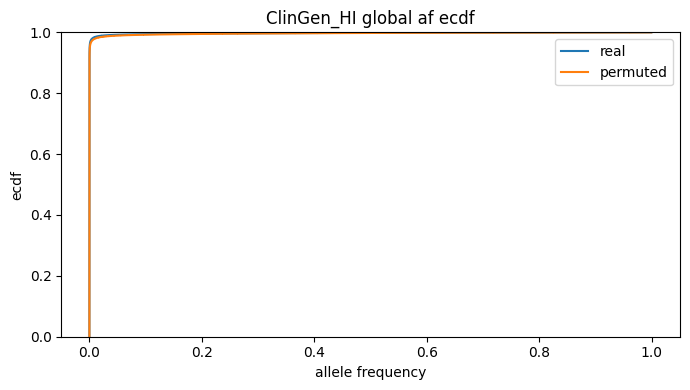

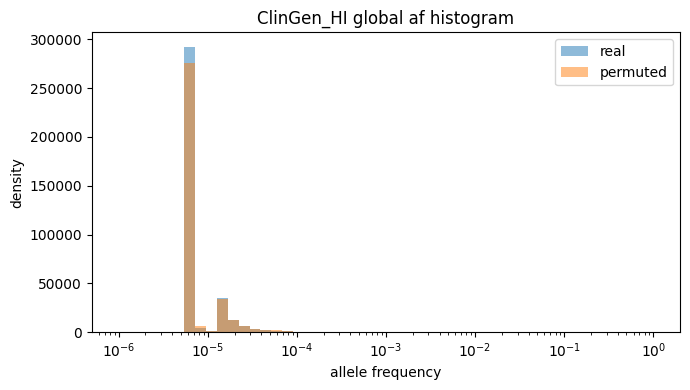

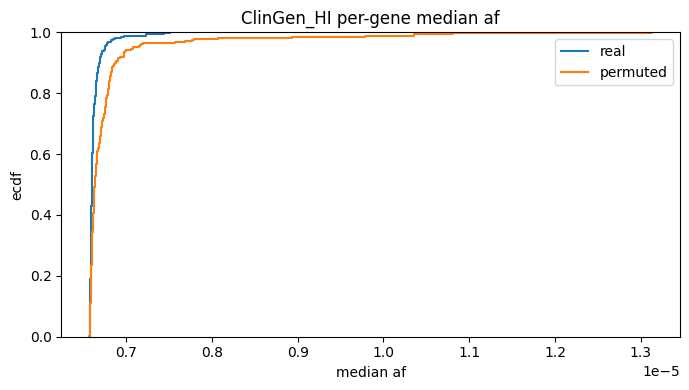

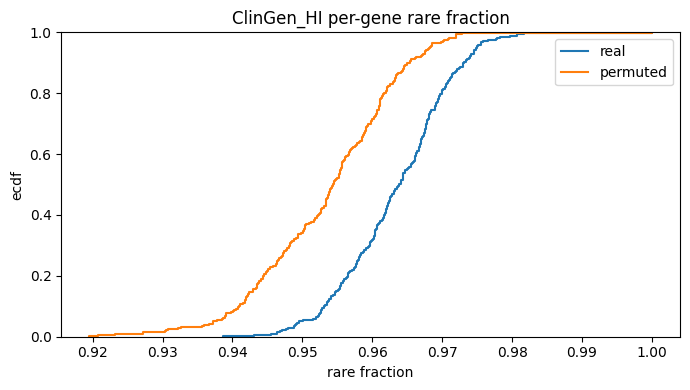

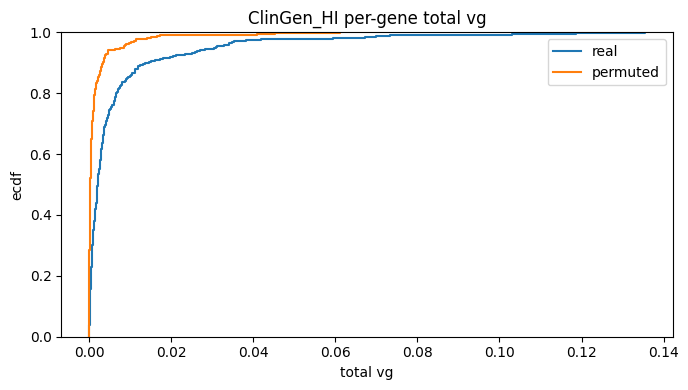

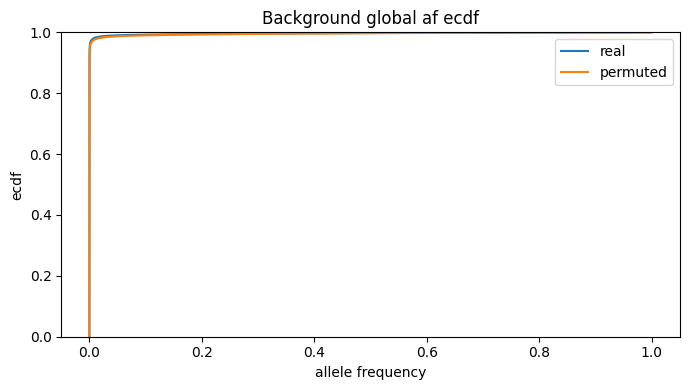

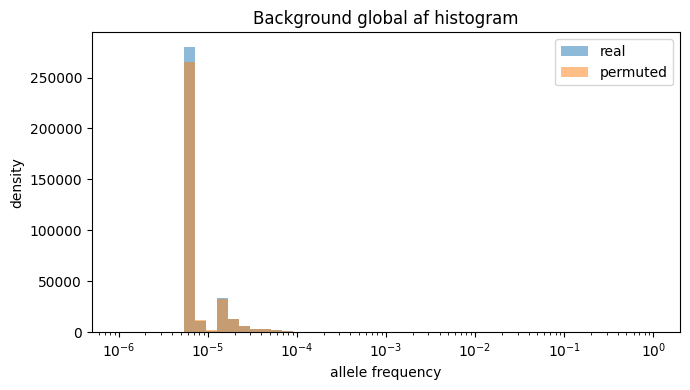

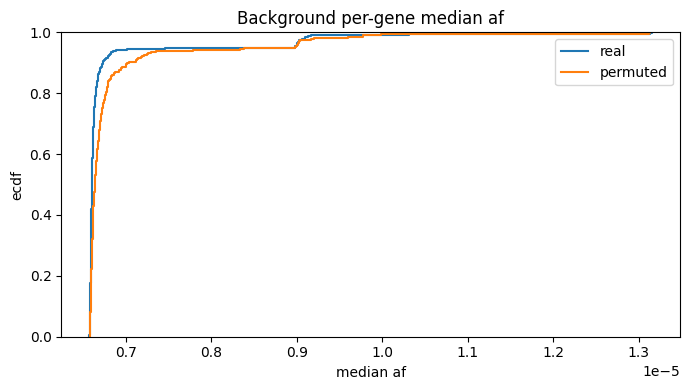

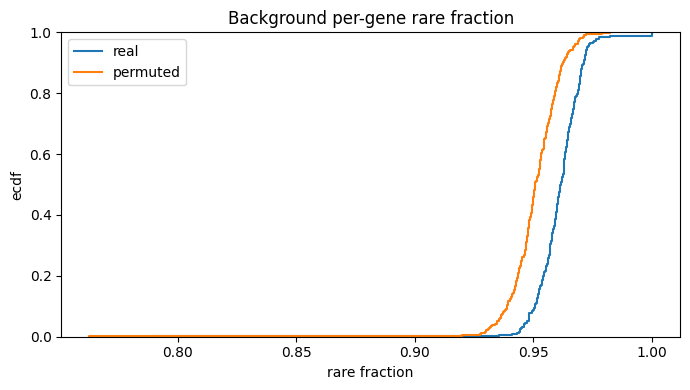

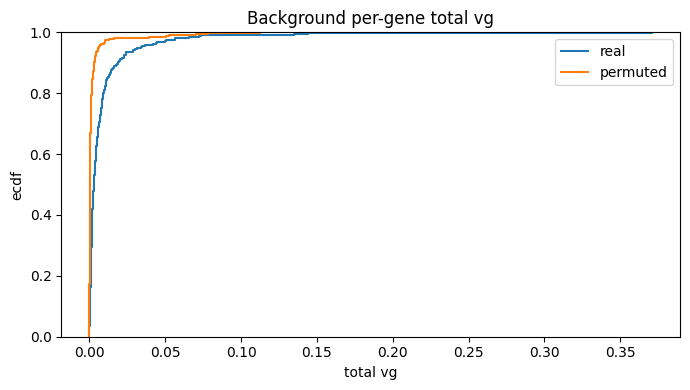

In [4]:
AF_RARE_THRESHOLD = 1e-3
MAX_SCATTER_POINTS = 20000





def _add_af_column(df: pl.DataFrame, dataset_name: str) -> pl.DataFrame:
    """add AF column from pre-processed dataframes.
    
    args:
        df (pl.DataFrame): deduplicated dataframe.
        dataset_name (str): 'clingen_real', 'clingen_null', 'background_real', or 'background_null'.
    
    returns:
        pl.DataFrame: dataframe with AF/perm_AF column added if needed.
    """
    # dataframes already have gene_id and scores, just need to extract AF
    # the AF information needs to be joined from the raw files or passed through
    # for now, return as is since we're just comparing distributions
    return df


def _variant_counts_per_gene(table: pl.DataFrame) -> pl.DataFrame:
    """count variants per gene.

    args:
        table (pl.DataFrame): variant table with gene_id.

    returns:
        pl.DataFrame: gene_id and n_variants.
    """
    return table.group_by('gene_id').agg(pl.len().alias('n_variants'))


def _median_af_per_gene(table: pl.DataFrame, af_col: str) -> pl.DataFrame:
    """compute per-gene median af.

    args:
        table (pl.DataFrame): variant table.
        af_col (str): af column name.

    returns:
        pl.DataFrame: gene_id and median_af.
    """
    return table.group_by('gene_id').agg(pl.col(af_col).median().alias('median_af'))


def _fraction_rare_per_gene(table: pl.DataFrame, af_col: str) -> pl.DataFrame:
    """compute per-gene rare-variant fraction.

    args:
        table (pl.DataFrame): variant table.
        af_col (str): af column name.

    returns:
        pl.DataFrame: gene_id and frac_rare.
    """
    return (
        table
        .with_columns((pl.col(af_col) < AF_RARE_THRESHOLD).cast(pl.Int8).alias('is_rare'))
        .group_by('gene_id')
        .agg(pl.col('is_rare').mean().alias('frac_rare'))
    )


def _sum_vg_per_gene(table: pl.DataFrame, vg_col: str) -> pl.DataFrame:
    """compute per-gene sum of vg.

    args:
        table (pl.DataFrame): variant table.
        vg_col (str): vg column name.

    returns:
        pl.DataFrame: gene_id and sum_vg.
    """
    return table.group_by('gene_id').agg(pl.col(vg_col).sum().alias('sum_vg'))


def _sample_for_scatter(df: pd.DataFrame, max_points: int) -> pd.DataFrame:
    """downsample for scatter plots.

    args:
        df (pd.DataFrame): data frame to sample.
        max_points (int): maximum points.

    returns:
        pd.DataFrame: sampled data.
    """
    if len(df) <= max_points:
        return df
    return df.sample(n=max_points, random_state=0)


def _plot_ecdf(real: pd.Series, null: pd.Series, title: str, xlabel: str) -> None:
    """plot ecdf for real vs permuted.

    args:
        real (pd.Series): real values.
        null (pd.Series): permuted values.
        title (str): plot title.
        xlabel (str): x-axis label.

    returns:
        None
    """
    plt.figure(figsize=(7, 4))
    sns.ecdfplot(real, label='real')
    sns.ecdfplot(null, label='permuted')
    plt.xlabel(xlabel)
    plt.ylabel('ecdf')
    plt.title(title)
    plt.legend()
    plt.tight_layout()


def _plot_af_hist(real: pd.Series, null: pd.Series, title: str) -> None:
    """plot global af log histogram.

    args:
        real (pd.Series): real af values.
        null (pd.Series): permuted af values.
        title (str): plot title.

    returns:
        None
    """
    bins = np.logspace(-6, 0, 50)
    plt.figure(figsize=(7, 4))
    plt.hist(real, bins=bins, alpha=0.5, label='real', density=True)
    plt.hist(null, bins=bins, alpha=0.5, label='permuted', density=True)
    plt.xscale('log')
    plt.xlabel('allele frequency')
    plt.ylabel('density')
    plt.title(title)
    plt.legend()
    plt.tight_layout()


def _plot_af_vg_scatter(
    real: pd.DataFrame,
    null: pd.DataFrame,
    af_col: str,
    null_af_col: str,
    vg_col: str,
    null_vg_col: str,
    title: str,
) -> None:
    """plot af vs vg with log10 scales.

    args:
        real (pd.DataFrame): real variants.
        null (pd.DataFrame): null variants.
        af_col (str): real af column.
        null_af_col (str): null af column.
        vg_col (str): real vg column.
        null_vg_col (str): null vg column.
        title (str): plot title.

    returns:
        None
    """
    real_sample = _sample_for_scatter(real, MAX_SCATTER_POINTS)
    null_sample = _sample_for_scatter(null, MAX_SCATTER_POINTS)

    real_x = np.log10(real_sample[af_col].to_numpy() + 1e-12)
    real_y = np.log10(real_sample[vg_col].to_numpy() + 1e-12)
    null_x = np.log10(null_sample[null_af_col].to_numpy() + 1e-12)
    null_y = np.log10(null_sample[null_vg_col].to_numpy() + 1e-12)

    plt.figure(figsize=(7, 4))
    sns.regplot(x=real_x, y=real_y, scatter_kws={'alpha': 0.1}, label='real')
    sns.regplot(x=null_x, y=null_y, scatter_kws={'alpha': 0.1}, label='permuted')
    plt.xlabel('log10(af)')
    plt.ylabel('log10(vg)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()


def _print_spearman(
    real: pd.DataFrame,
    null: pd.DataFrame,
    af_col: str,
    null_af_col: str,
    vg_col: str,
    null_vg_col: str,
    label: str,
    ) -> None:
    """print spearman correlations.

    args:
        real (pd.DataFrame): real variants.
        null (pd.DataFrame): null variants.
        af_col (str): real af column.
        null_af_col (str): null af column.
        vg_col (str): real vg column.
        null_vg_col (str): null vg column.
        label (str): dataset label.

    returns:
        None
    """
    real_corr = stats.spearmanr(real[af_col], real[vg_col]).correlation
    null_corr = stats.spearmanr(null[null_af_col], null[null_vg_col]).correlation
    print(f'{label} spearman real={real_corr:.3f} permuted={null_corr:.3f}')


# use pre-processed dataframes from debug cell
datasets = {
    'clingen': {
        'label': 'ClinGen_HI',
        'real_dedup': clingen_real_dedup,
        'null_sampled': clingen_null_sampled,
        'real_gene_path': GENE_PATHS['clingen'],
        'null_gene_path': GENE_PATHS['clingen_null'],
        'af_col': 'AF',
        'null_af_col': 'perm_AF',
    },
    'background': {
        'label': 'Background',
        'real_dedup': background_real_dedup,
        'null_sampled': background_null_sampled,
        'real_gene_path': GENE_PATHS['background'],
        'null_gene_path': GENE_PATHS['background_null'],
        'af_col': 'AF',
        'null_af_col': 'perm_AF',
    },
}

for name, cfg in datasets.items():
    label = cfg['label']

    # use pre-processed deduplicated and downsampled dataframes
    real_table = cfg['real_dedup']
    null_table = cfg['null_sampled']

    print(f'{label} real dedup shape: {real_table.shape}')
    print(f'{label} null sampled shape: {null_table.shape}')

    real = real_table.to_pandas()
    null = null_table.to_pandas()

    af_col = cfg['af_col']
    null_af_col = cfg['null_af_col']
    
    print(f"\n{'='*60}")
    print(f"{label} SUMMARY STATISTICS")
    print(f"{'='*60}")
    
    # variant counts
    print(f"\nvariant counts:")
    print(f"  real: {len(real)} variants, {real['gene_id'].nunique()} genes")
    print(f"  null: {len(null)} variants, {null['gene_id'].nunique()} genes")
    
    # global af statistics
    print(f"\nglobal {af_col} statistics:")
    print(f"  real:  mean={real[af_col].mean():.6e}, median={real[af_col].median():.6e}, "
          f"std={real[af_col].std():.6e}")
    print(f"  null:  mean={null[null_af_col].mean():.6e}, median={null[null_af_col].median():.6e}, "
          f"std={null[null_af_col].std():.6e}")
    print(f"  quantiles (real):  q05={real[af_col].quantile(0.05):.6e}, "
          f"q50={real[af_col].quantile(0.50):.6e}, q95={real[af_col].quantile(0.95):.6e}")
    print(f"  quantiles (null):  q05={null[null_af_col].quantile(0.05):.6e}, "
          f"q50={null[null_af_col].quantile(0.50):.6e}, q95={null[null_af_col].quantile(0.95):.6e}")
    
    # af range
    print(f"\naf range:")
    print(f"  real:  min={real[af_col].min():.6e}, max={real[af_col].max():.6e}")
    print(f"  null:  min={null[null_af_col].min():.6e}, max={null[null_af_col].max():.6e}")
    
    # phase 1: global af distributions
    _plot_ecdf(real[af_col], null[null_af_col], f'{label} global af ecdf', 'allele frequency')
    _plot_af_hist(real[af_col], null[null_af_col], f'{label} global af histogram')

    ks = stats.ks_2samp(real[af_col], null[null_af_col])
    print(f'\n{label} global af KS test: stat={ks.statistic:.3e} p={ks.pvalue:.3e}')

    # phase 2: per-gene af statistics (counts match by design after downsampling)
    real_median = _median_af_per_gene(real_table, af_col).to_pandas()['median_af']
    null_median = _median_af_per_gene(null_table, null_af_col).to_pandas()['median_af']
    
    print(f"\nper-gene median af:")
    print(f"  real:  mean={real_median.mean():.6e}, median={real_median.median():.6e}, "
          f"std={real_median.std():.6e}")
    print(f"  null:  mean={null_median.mean():.6e}, median={null_median.median():.6e}, "
          f"std={null_median.std():.6e}")
    print(f"  real range:  [{real_median.min():.6e}, {real_median.max():.6e}]")
    print(f"  null range:  [{null_median.min():.6e}, {null_median.max():.6e}]")
    
    _plot_ecdf(real_median, null_median, f'{label} per-gene median af', 'median af')
    
    ks_median = stats.ks_2samp(real_median, null_median)
    print(f'  KS test: stat={ks_median.statistic:.3e} p={ks_median.pvalue:.3e}')

    real_frac = _fraction_rare_per_gene(real_table, af_col).to_pandas()['frac_rare']
    null_frac = _fraction_rare_per_gene(null_table, null_af_col).to_pandas()['frac_rare']
    
    print(f"\nper-gene rare fraction (af < {AF_RARE_THRESHOLD}):")
    print(f"  real:  mean={real_frac.mean():.4f}, median={real_frac.median():.4f}, "
          f"std={real_frac.std():.4f}")
    print(f"  null:  mean={null_frac.mean():.4f}, median={null_frac.median():.4f}, "
          f"std={null_frac.std():.4f}")
    print(f"  real range:  [{real_frac.min():.4f}, {real_frac.max():.4f}]")
    print(f"  null range:  [{null_frac.min():.4f}, {null_frac.max():.4f}]")
    
    _plot_ecdf(real_frac, null_frac, f'{label} per-gene rare fraction', 'rare fraction')
    
    ks_frac = stats.ks_2samp(real_frac, null_frac)
    print(f'  KS test: stat={ks_frac.statistic:.3e} p={ks_frac.pvalue:.3e}')

    # phase 3: gene-level vg comparison
    real_gene = pl.read_parquet(cfg['real_gene_path'], columns=['vg_predicted'])
    real_vg = real_gene['vg_predicted'].to_pandas()

    null_gene = pl.read_parquet(cfg['null_gene_path'], columns=['vg_predicted_perm'])
    null_vg = null_gene['vg_predicted_perm'].to_pandas()
    
    print(f"\nper-gene vg:")
    print(f"  real:  mean={real_vg.mean():.6e}, median={real_vg.median():.6e}")
    print(f"  null:  mean={null_vg.mean():.6e}, median={null_vg.median():.6e}")
    
    _plot_ecdf(real_vg, null_vg, f'{label} per-gene total vg', 'total vg')
    
    ks_vg = stats.ks_2samp(real_vg, null_vg)
    print(f'  KS test: stat={ks_vg.statistic:.3e} p={ks_vg.pvalue:.3e}')
    
    # check for per-gene af issues
    print(f"\n{'='*60}")
    print(f"DIAGNOSTIC: per-gene AF distribution")
    print(f"{'='*60}")
    real_per_gene = real_table.group_by('gene_id').agg([
        pl.col(af_col).mean().alias('mean_af'),
        pl.col(af_col).median().alias('median_af'),
        pl.len().alias('n_variants')
    ]).to_pandas()
    null_per_gene = null_table.group_by('gene_id').agg([
        pl.col(null_af_col).mean().alias('mean_af'),
        pl.col(null_af_col).median().alias('median_af'),
        pl.len().alias('n_variants')
    ]).to_pandas()
    
    print(f"\nexample genes (top 5 by variant count):")
    print(f"\nreal:")
    print(real_per_gene.nlargest(5, 'n_variants')[['gene_id', 'n_variants', 'mean_af', 'median_af']])
    print(f"\nnull:")
    print(null_per_gene.nlargest(5, 'n_variants')[['gene_id', 'n_variants', 'mean_af', 'median_af']])
    
    # check if AFs are from the same source
    print(f"\n{'='*60}")
    print(f"DIAGNOSTIC: AF Source Comparison")
    print(f"{'='*60}")
    print(f"\nHypothesis: perm_AF is randomly sampled from a global pool")
    print(f"  → This breaks gene-specific AF patterns")
    print(f"  → Results in different per-gene distributions")
    
    # compare a specific gene's AFs
    example_gene = real_per_gene.nlargest(1, 'n_variants').iloc[0]['gene_id']
    real_gene_afs = real[real['gene_id'] == example_gene][af_col].values
    null_gene_afs = null[null['gene_id'] == example_gene][null_af_col].values
    
    print(f"\nExample: gene {example_gene} (largest gene)")
    print(f"  real AF stats:  mean={real_gene_afs.mean():.6e}, median={np.median(real_gene_afs):.6e}")
    print(f"  null AF stats:  mean={null_gene_afs.mean():.6e}, median={np.median(null_gene_afs):.6e}")
    print(f"  ⚠️  If perm_AF is from random global sampling, null should be close to global mean")
    print(f"  Global mean (all genes): real={real[af_col].mean():.6e}, null={null[null_af_col].mean():.6e}")